# Matrice di acquisizione: Heatmap che mostra la distribuzione dei campioni per coppia (source × attribute), evidenziando le celle vuote (combinazioni semanticamente invalide) e le aree di densità.

In [1]:
import asyncio
import pandas as pd
import plotly.express as px
import sys
import os
sys.path.append(os.path.abspath("../.."))
import logging
import numpy as np
import pandas as pd
import plotly.express as px
import umap
import sys
import os

logging.getLogger('numba').setLevel(logging.WARNING)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('plotly.express').setLevel(logging.WARNING)
logging.getLogger('kaleido').setLevel(logging.WARNING)
from core.infrastructure.database.dependecies import get_audio_repository

async def plot_acquisition_matrix():
    print("Connessione al Database Audio...")
    repo = get_audio_repository()

    docs = await repo.find_all()
    print(f"Scaricati {len(docs)} documenti. Elaborazione matrice...")

    if not docs:
        print("Nessun dato trovato nel DB.")
        return

    # 2. Estrazione Feature (Instrument vs Attribute)
    data = []

    for doc in docs:
        # A. SOURCE = STRUMENTO (Main Category)
        instrument = doc.metadata.main_category
        if not instrument:
            continue # Ignoriamo file senza categoria principale

        # Pulizia base
        instrument = instrument.replace("?", "").strip().title()

        # B. ATTRIBUTE = TAGS (Descriptors)
        # Un file può avere N attributi, quindi creiamo N righe per questo file
        tags = doc.metadata.categories or ["Uncategorized"]

        # Se è una stringa singola invece di una lista, correggiamo
        if isinstance(tags, str):
            tags = [tags]

        for tag in tags:
            tag_clean = tag.strip().lower()

            # Filtro opzionale: rimuoviamo tag troppo generici che sporcano la matrice
            if tag_clean in ["loop", "oneshot", "stereo", "44.1khz"]:
                continue

            data.append({
                "Source (Instrument)": instrument,
                "Attribute (Tag)": tag_clean
            })

    # 3. Creazione DataFrame
    df = pd.DataFrame(data)

    print(df['Source (Instrument)'].unique())

    if df.empty:
        print("Non ci sono abbastanza dati (o tag) per generare la matrice.")
        return

    # Creiamo la matrice di conteggio
    # Righe = Strumento, Colonne = Attributo
    matrix = pd.crosstab(df['Source (Instrument)'], df['Attribute (Tag)'])

    # Filtriamo eventuali attributi troppo rari per rendere il grafico leggibile (Opzionale)
    # Tieni solo i top 50 attributi per frequenza, o mostra tutto se sono pochi
    if len(matrix.columns) > 60:
        top_attributes = matrix.sum().nlargest(50).index
        matrix = matrix[top_attributes]

    # 4. Visualizzazione Heatmap
    fig = px.imshow(
        matrix,
        labels=dict(x="Attribute (Semantic Tag)", y="Source (Instrument)", color="Count"),
        x=matrix.columns,
        y=matrix.index,
        text_auto=True,       # Mostra i numeri
        aspect="auto",
        color_continuous_scale="RdBu_r", # Rosso=Denso, Blu/Bianco=Vuoto
        origin='lower'
    )

    fig.update_layout(
        title=f"<b>Acquisition Matrix</b><br>Semantic Coverage: Instrument vs Attributes",
        title_x=0.5,
        width=1200,
        height=800,
        xaxis={'side': 'bottom', 'tickangle': -45},
        yaxis={'title': 'Source (Instrument)'}
    )

    fig.show()
    fig.to_html("./aquisition_matrix.html")
    fig.to_image(format="png")

# Esecuzione
await plot_acquisition_matrix()

H:\music-ai\venvmusic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:core.infrastructure.database.dependecies:Connecting to MongoDB at: mongodb://localhost:27017/
DEBUG:core.infrastructure.database.dependecies:Getting database: audio_db
DEBUG:core.infrastructure.database.dependecies:Getting audio collection: audio_samples


Connessione al Database Audio...
Scaricati 1028 documenti. Elaborazione matrice...
['Analog-Synth-Bass' 'Bass-Line' 'Sub-Bass' 'Digital-Synth-Bass' 'Toms'
 'Claps' 'Rides' 'Lead' 'Synth-Fx']


DEBUG:asyncio:Using selector: SelectSelector
DEBUG:choreographer.browser_async:Attempting to open new browser.
INFO:choreographer.browsers.chromium:Chromium init'ed with kwargs {}
DEBUG:choreographer.browsers.chromium:Looking for a chrome browser.
DEBUG:root:Looking for browser, skipping local? False
DEBUG:root:Looking for at local chrome download path: H:\music-ai\venvmusic\Lib\site-packages\choreographer\cli\browser_exe\chrome-win64\chrome.exe
DEBUG:root:Local chrome not found at path: H:\music-ai\venvmusic\Lib\site-packages\choreographer\cli\browser_exe\chrome-win64\chrome.exe.
INFO:choreographer.browsers.chromium:Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe
INFO:choreographer.utils._tmpfile:Temp directory created: C:\Users\marti\AppData\Local\Temp\tmppshhv85j.
INFO:choreographer.browser_async:Opening browser.
DEBUG:choreographer.browser_async:Trying to open browser.
INFO:choreographer.utils._tmpfile:Temp directory created: C:\Users\marti\AppData\Local\

In [2]:
async def plot_timbre_matrix():
    print("Connessione al Database Audio...")
    repo = get_audio_repository()

    docs = await repo.find_all()
    print(f"Analisi di {len(docs)} documenti per i timbri richiesti...")

    if not docs:
        print("Nessun dato trovato.")
        return

    target_timbres = [
        "warm", "cold", "soft", "happy",
        "heavy", "airy", "bright", "dark"
    ]

    data = []

    for doc in docs:
        # A. STRUMENTO (Main Category)
        instrument = doc.metadata.main_category
        if not instrument:
            continue

        instrument = instrument.replace("?", "").strip().title()

        # B. TIMBRO (Tags)
        tags = doc.metadata.categories or []
        if isinstance(tags, str):
            tags = [tags]

        for tag in tags:
            tag_clean = tag.strip().lower()

            if tag_clean in target_timbres:
                data.append({
                    "Source (Instrument)": instrument,
                    "Timbre": tag_clean
                })

    df = pd.DataFrame(data)

    if df.empty:
        print("Nessuno dei timbri richiesti è stato trovato nel dataset.")
        return

    matrix = pd.crosstab(df['Source (Instrument)'], df['Timbre'])
    existing_columns = [t for t in target_timbres if t in matrix.columns]
    matrix = matrix[existing_columns]

    # 5. Visualizzazione
    fig = px.imshow(
        matrix,
        labels=dict(x="Timbre Attribute", y="Instrument Source", color="Count"),
        x=matrix.columns,
        y=matrix.index,
        text_auto=True,
        aspect="auto",
        color_continuous_scale="RdBu_r", # Rosso = Molto presente, Blu = Assente
        origin='lower'
    )

    fig.update_layout(
        title=f"<b>Timbre Distribution Matrix</b><br>Focus on specific tonal characteristics",
        title_x=0.5,
        width=1000,
        height=600,
        xaxis={'side': 'bottom', 'title': 'Timbre'},
        yaxis={'title': 'Instrument'}
    )

    fig.show()

await plot_timbre_matrix()

Connessione al Database Audio...
Analisi di 1028 documenti per i timbri richiesti...


In [3]:
import asyncio
import pandas as pd
from collections import Counter
from qdrant_client import QdrantClient
import sys
import os

# Setup Path
sys.path.append(os.path.abspath("../.."))
from config.settings import settings

# --- CONFIGURAZIONE ---
QDRANT_COLLECTION = settings.QDRANT_ENRICHED_COLLECTION_NAME
SAMPLE_LIMIT = 10000  # Mettiamo un limite alto per prendere TUTTO il dataset (828 samples)

# Lista di aggettivi percettivi per filtrare i tag (espandibile)
PERCEPTUAL_KEYWORDS = {
    "warm", "bright", "dark", "punchy", "distorted", "clean", "dry", "wet",
    "fuzzy", "shimmering", "deep", "aggressive", "soft", "hard", "metallic",
    "wooden", "glassy", "granular", "lo-fi", "hi-fi", "fat", "thin", "heavy"
}

async def generate_dataset_statistics():
    print("--- 5.1 DATASET STATISTICS & DISTRIBUTION ---")
    client = QdrantClient(host=settings.QDRANT_CONNECTION_HOST, port=settings.QDRANT_PORT)

    # 1. Recupero Dati
    scroll_res, _ = client.scroll(
        collection_name=QDRANT_COLLECTION,
        limit=SAMPLE_LIMIT,
        with_vectors=False,
        with_payload=True
    )

    if not scroll_res:
        print("Nessun dato trovato.")
        return

    total_samples = len(scroll_res)
    print(f"Total Samples Retrieved: {total_samples}")

    data = []
    all_ai_tags = []
    all_raw_tags = []

    for hit in scroll_res:
        payload = hit.payload or {}

        # Estrazione Campi
        cat = payload.get('main_category', 'Uncategorized')
        # Se main_category è vuota o generica, proviamo a dedurla dal primo tag AI
        if not cat or cat == "Uncategorized":
            tags = payload.get('ai_tags', [])
            if tags: cat = tags[0].title()

        ai_tags = payload.get('ai_tags', [])
        raw_tags = payload.get('original_tags', [])

        # Normalizzazione liste
        if not isinstance(ai_tags, list): ai_tags = []
        if not isinstance(raw_tags, list): raw_tags = []

        all_ai_tags.extend([t.lower() for t in ai_tags])
        all_raw_tags.extend([str(t).lower() for t in raw_tags])

        data.append({
            "Category": cat,
            "AI Tags Count": len(ai_tags),
            "Raw Tags Count": len(raw_tags),
            "AI Tags": ai_tags
        })

    df = pd.DataFrame(data)

    # ==========================================
    # TABELLA 1: OVERVIEW (Before vs After)
    # ==========================================
    print("\n--- TABLE 1: DATASET HEALTH & CLEANING IMPACT ---")

    unique_ai = len(set(all_ai_tags))
    unique_raw = len(set(all_raw_tags))

    overview_data = {
        "Metric": [
            "Total Samples",
            "Total Unique Tags (Vocabulary)",
            "Avg Tags per Sample",
            "Vocabulary Density (Tags/Sample ratio)"
        ],
        "Before (Raw Metadata)": [
            total_samples,
            unique_raw,
            f"{len(all_raw_tags)/total_samples:.1f}",
            f"{unique_raw/total_samples:.2f} (High Noise)"
        ],
        "After (AI Enriched)": [
            total_samples,
            unique_ai,
            f"{len(all_ai_tags)/total_samples:.1f}",
            f"{unique_ai/total_samples:.2f} (Controlled)"
        ]
    }

    display(pd.DataFrame(overview_data))


    # ==========================================
    # TABELLA 2: CATEGORY DISTRIBUTION (Balance)
    # ==========================================
    print("\n--- TABLE 2: DISTRIBUTION ACROSS MAIN CATEGORIES ---")

    cat_counts = df['Category'].value_counts().reset_index()
    cat_counts.columns = ['Category', 'Count']
    cat_counts['Percentage'] = (cat_counts['Count'] / total_samples * 100).map('{:.1f}%'.format)

    # Aggiungiamo una colonna "Balance Check"
    avg_count = cat_counts['Count'].mean()
    cat_counts['Status'] = cat_counts['Count'].apply(
        lambda x: "Dominant" if x > avg_count * 1.5 else ("Rare" if x < avg_count * 0.5 else "Balanced")
    )

    display(cat_counts)


    # ==========================================
    # TABELLA 3: PERCEPTUAL DESCRIPTORS (Retrieval Readiness)
    # ==========================================
    print("\n--- TABLE 3: TOP PERCEPTUAL DESCRIPTORS (Adjectives) ---")

    # Filtriamo solo i tag che sono aggettivi percettivi (escludiamo "bass", "drum", "loop")
    perceptual_tags = [t for t in all_ai_tags if t in PERCEPTUAL_KEYWORDS]

    if not perceptual_tags:
        # Fallback: se la lista keyword è troppo stretta, mostriamo i top tag generici esclusi gli strumenti
        stopwords = {"bass", "drum", "drums", "synth", "loop", "one", "shot", "sample", "sound", "fx", "percussion"}
        perceptual_tags = [t for t in all_ai_tags if t not in stopwords]
        print("(Nota: Filtraggio euristico attivato per mostrare i descrittori più comuni)")

    desc_counts = Counter(perceptual_tags).most_common(10)

    desc_df = pd.DataFrame(desc_counts, columns=['Descriptor', 'Frequency'])
    desc_df['Coverage'] = (desc_df['Frequency'] / total_samples * 100).map('{:.1f}%'.format)

    display(desc_df)
    print(f"Total Perceptual Tag Occurrences: {len(perceptual_tags)}")

# Esecuzione
# asyncio.run(generate_dataset_statistics())
await generate_dataset_statistics()

--- 5.1 DATASET STATISTICS & DISTRIBUTION ---


DEBUG:httpcore.connection:connect_tcp.started host='localhost' port=6333 local_address=None timeout=5.0 socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x0000028F27183BB0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'transfer-encoding', b'chunked'), (b'content-type', b'application/json'), (b'content-encoding', b'br'), (b'vary', b'accept-encoding, Origin, Access-Control-Request-Method, Access-Control-Request-Headers'), (b'date', b'Thu, 12 Feb 2026 23:49:46 GMT')])
INFO:httpx:HTTP Request: GET http://localhost:6333 "HTTP/1.1 200

Total Samples Retrieved: 995

--- TABLE 1: DATASET HEALTH & CLEANING IMPACT ---


,Metric,Before (Raw Metadata),After (AI Enriched)
0,Total Samples,995,995
1,Total Unique Tags (Vocabulary),273,246
2,Avg Tags per Sample,8.7,5.7
3,Vocabulary Density (Tags/Sample ratio),0.27 (High Noise),0.25 (Controlled)



--- TABLE 2: DISTRIBUTION ACROSS MAIN CATEGORIES ---


,Category,Count,Percentage,Status
0,digital-synth-bass,134,13.5%,Balanced
1,analog-synth-bass,125,12.6%,Balanced
2,bass-line,125,12.6%,Balanced
3,synth-fx,123,12.4%,Balanced
4,lead,119,12.0%,Balanced
5,claps,111,11.2%,Balanced
6,toms,107,10.8%,Balanced
7,sub-bass,86,8.6%,Balanced
8,rides,65,6.5%,Balanced



--- TABLE 3: TOP PERCEPTUAL DESCRIPTORS (Adjectives) ---


,Descriptor,Frequency,Coverage
0,dry,469,47.1%
1,clean,446,44.8%
2,hard,190,19.1%
3,dark,183,18.4%
4,warm,171,17.2%
5,soft,146,14.7%
6,bright,129,13.0%
7,aggressive,109,11.0%
8,heavy,85,8.5%
9,distorted,64,6.4%


Total Perceptual Tag Occurrences: 2044


# ENRICHMENT

INFO:choreographer.utils._tmpfile:TemporaryDirectory.cleanup() worked.
INFO:choreographer.utils._tmpfile:shutil.rmtree worked.
DEBUG:httpcore.connection:connect_tcp.started host='localhost' port=6333 local_address=None timeout=5.0 socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x0000028F2A5ED570>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'transfer-encoding', b'chunked'), (b'vary', b'accept-encoding, Origin, Access-Control-Request-Method, Access-Control-Request-Headers'), (b'content-encoding', b'br'), (b'content-type', b'app

--- RECUPERO DATI E CALCOLO DIFFERENZE ---
Analisi differenziale su 995 campioni...
Generazione Grafico...


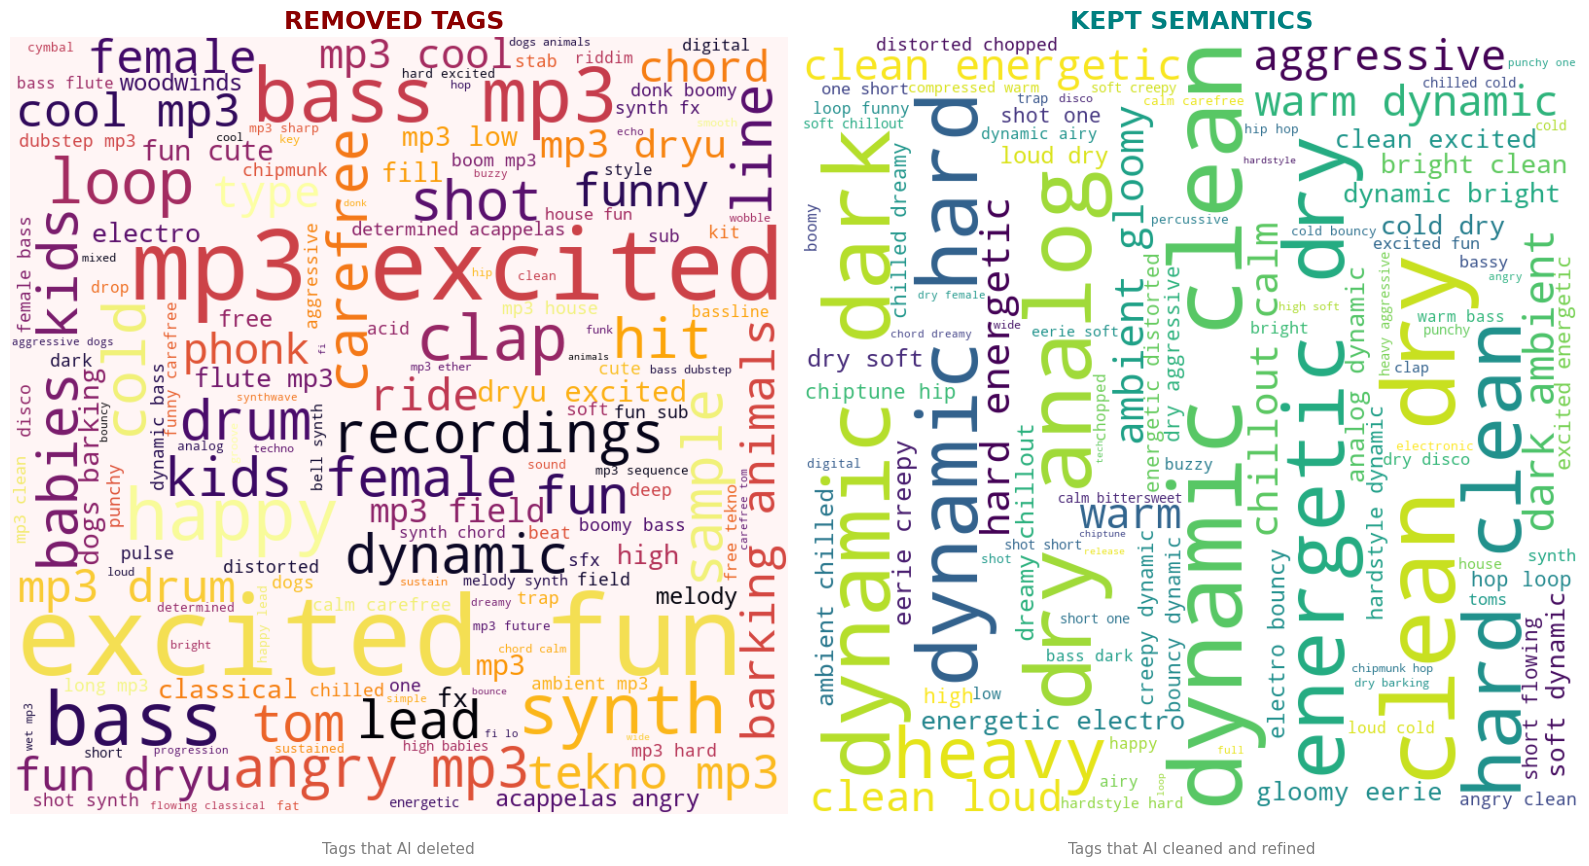

In [4]:
import asyncio
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from qdrant_client import QdrantClient
import re
import sys
import os

# Setup Path
sys.path.append(os.path.abspath("../.."))
from config.settings import settings

# --- CONFIGURAZIONE ---
QDRANT_COLLECTION = settings.QDRANT_ENRICHED_COLLECTION_NAME
SAMPLE_LIMIT = 1500

def tokenize(text_list):
    """
    Spezza le stringhe in singole parole (token) per poter fare la sottrazione.
    Gestisce separatori come underscore, trattini e punti.
    """
    text_block = " ".join(text_list).lower()
    # Sostituiamo caratteri "tecnici" con spazi per isolare le parole
    text_block = text_block.replace("_", " ").replace("-", " ").replace(".", " ")
    # Ritorniamo un set di parole uniche
    return set(text_block.split())

def generate_diff_wordcloud():
    print("--- RECUPERO DATI E CALCOLO DIFFERENZE ---")
    client = QdrantClient(host=settings.QDRANT_CONNECTION_HOST, port=settings.QDRANT_PORT)

    scroll_res, _ = client.scroll(
        collection_name=QDRANT_COLLECTION,
        limit=SAMPLE_LIMIT,
        with_vectors=False,
        with_payload=True
    )

    if not scroll_res:
        print("Nessun dato trovato.")
        return

    print(f"Analisi differenziale su {len(scroll_res)} campioni...")

    removed_noise_pool = [] # Parole che c'erano prima e ora non ci sono più
    kept_semantic_pool = [] # Le parole finali (il risultato pulito)

    for hit in scroll_res:
        payload = hit.payload or {}

        # 1. INSIEME ORIGINALE (Dirty)
        orig_tags = payload.get('original_tags', [])
        filename = payload.get('original_filename', "")

        # Uniamo filename e tag originali come "Fonte Sporca"
        source_list = [filename]
        if isinstance(orig_tags, list):
            source_list.extend(orig_tags)
        elif orig_tags:
            source_list.append(str(orig_tags))

        original_tokens = tokenize(source_list)

        # 2. INSIEME FINALE (Clean)
        ai_tags = payload.get('ai_tags', [])
        label = payload.get('label', "")

        dest_list = [label]
        if ai_tags:
            dest_list.extend(ai_tags)

        final_tokens = tokenize(dest_list)

        # 3. CALCOLO DELLA DIFFERENZA (Il "Rumore" rimosso)
        # Rumore = Ciò che sta nell'Originale MENO ciò che sta nel Finale
        # Es: Originale={"bass", "loop", "wav", "128"}, Finale={"bass", "warm"}
        # Rumore = {"loop", "wav", "128"} ("bass" si salva perché è valido)
        noise_tokens = original_tokens - final_tokens

        removed_noise_pool.extend(list(noise_tokens))
        kept_semantic_pool.extend(list(final_tokens))

    # --- GENERAZIONE TESTO ---
    text_noise = " ".join(removed_noise_pool)
    text_clean = " ".join(kept_semantic_pool)

    # Configurazione Stopwords
    # Per il rumore, VOGLIAMO vedere estensioni e termini tecnici, quindi siamo meno aggressivi
    noise_stopwords = set(STOPWORDS)
    # Rimuoviamo parole troppo comuni che non sono interessanti nemmeno come rumore
    noise_stopwords.update(["unknown", "file", "nan"])

    print("Generazione Grafico...")

    # --- PLOT ---
    plt.figure(figsize=(16, 9))

    # 1. CLOUD DEL RUMORE (Rosso/Grigio)
    wc_noise = WordCloud(
        width=800, height=800,
        background_color='#fff5f5',
        stopwords=noise_stopwords,
        colormap='inferno',
        min_font_size=8,
        max_words=150,
        regexp=r"\w[\w']+"
    ).generate(text_noise)

    plt.subplot(1, 2, 1)
    plt.imshow(wc_noise, interpolation="bilinear")
    plt.title("REMOVED TAGS ", fontsize=18, color='darkred', fontweight='bold')
    plt.axis("off")
    plt.text(0.5, -0.05, "Tags that AI deleted",
             ha='center', transform=plt.gca().transAxes, fontsize=11, color='gray')

    # 2. CLOUD SEMANTICA (Blu/Verde)
    wc_clean = WordCloud(
        width=800, height=800,
        background_color='white',
        stopwords=noise_stopwords,
        colormap='viridis', # Colore pulito e professionale
        min_font_size=10,
        max_words=100
    ).generate(text_clean)

    plt.subplot(1, 2, 2)
    plt.imshow(wc_clean, interpolation="bilinear")
    plt.title("KEPT SEMANTICS", fontsize=18, color='teal', fontweight='bold')
    plt.axis("off")
    plt.text(0.5, -0.05, "Tags that AI cleaned and refined",
             ha='center', transform=plt.gca().transAxes, fontsize=11, color='gray')

    plt.tight_layout()
    plt.savefig(fname="wordcloud.png")

    plt.show()

# Esecuzione
generate_diff_wordcloud()